# Analisis Eksplorasi Data (EDA) dan Uji Coba Model Awal

Dalam notebook ini kita akan melakukan eksplorasi data secara visual untuk melihat bagaimana fitur atau variabel yang ada di dataset berkorelasi terhadap posisi final di balapan. Setelah itu, akan dilakukan uji coba komputasi Machine Learning tingkat dasar.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

### 1. Memuat Dataset

Membaca data turunan hasil eksekusi `process_data.py` dari direktori `data/`.

In [3]:
file_path = '../data/f1_processed.csv'
df = pd.read_csv(file_path)

print(f"Total observasi: {len(df)}")
df.head()

Total observasi: 958


,Season,Round,CircuitName,DriverAbbreviation,TeamName,GridPosition,FinalPosition
0,2024,1,Bahrain Grand Prix,VER,Red Bull Racing,1,1
1,2024,1,Bahrain Grand Prix,LEC,Ferrari,2,4
2,2024,1,Bahrain Grand Prix,RUS,Mercedes,3,5
3,2024,1,Bahrain Grand Prix,SAI,Ferrari,4,3
4,2024,1,Bahrain Grand Prix,PER,Red Bull Racing,5,2


### 2. Scatter Plot: Posisi Grid Awal Vs Hasil Akhir Balapan

Hubungan paling fundamental yang bisa dianalisis adalah efek dari di mana seorang pembalap memulai balapannya (`GridPosition`) dengan di mana pembalap tersebut menyelesaikannya (`FinalPosition`).

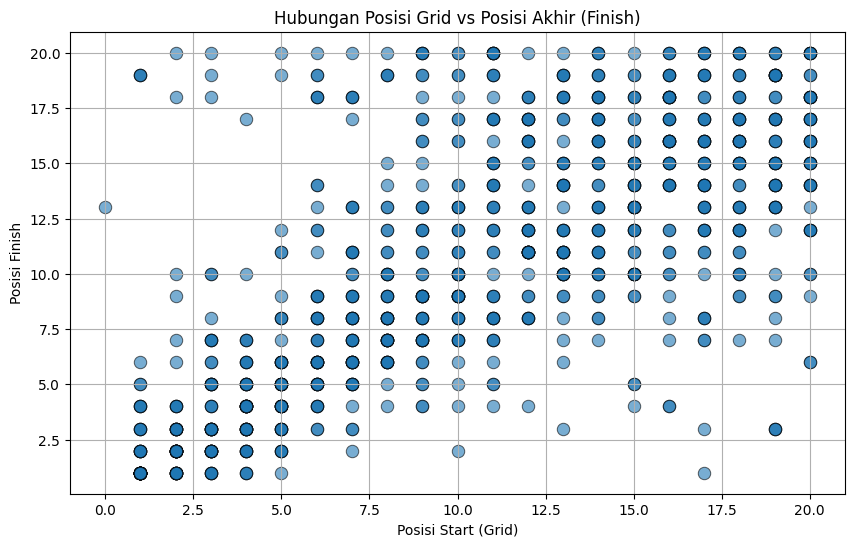

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GridPosition', y='FinalPosition', alpha=0.6, edgecolor='k', s=80)
plt.title('Hubungan Posisi Grid vs Posisi Akhir (Finish)')
plt.xlabel('Posisi Start (Grid)')
plt.ylabel('Posisi Finish')
plt.grid(True)
plt.show()

### 3. Matriks Korelasi (Heatmap)

Digunakan untuk melihat seberapa kuat variabel numerik saling berinteraksi (korelasi pearson) dan melihat mana yang korelasinya terhadap `FinalPosition` paling tebal.

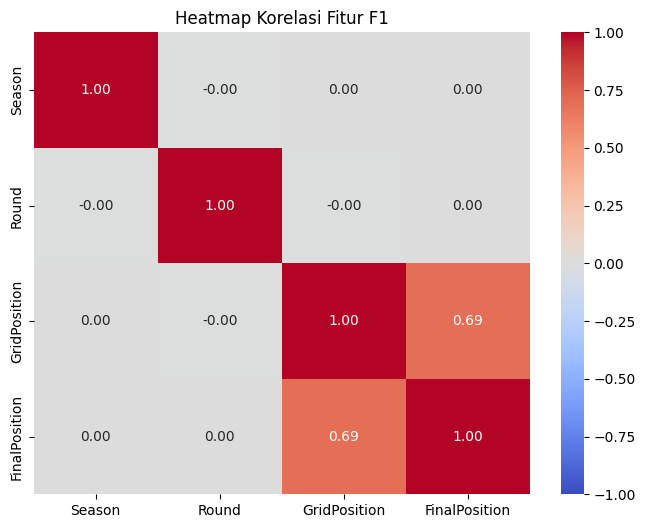

In [5]:
# Filter hanya pada kolom berskala numerik
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur F1')
plt.show()

### 4. Pengujian Awal Machine Learning

Sebagai percobaan awal, kita menggunakan **Random Forest Regressor** pada data (dilakukan *One-Hot Encoding* sejenak untuk menampung properti teks seperti nama sirkuit/tim agar bisa diproses). Tujuannya sebatas melihat efikasi persentase keakuratan tebakan awal ($R^2$ Score) sebelum model aslinya dioptimasi.

In [6]:
# Pre-processing sederhana: Merubah data ketegori String menjadi kolom biner matematis
df_encoded = pd.get_dummies(df, columns=['CircuitName', 'DriverAbbreviation', 'TeamName'], drop_first=True)

# Memisahkan target tebakan ('FinalPosition') dari matriks fitur independen
X = df_encoded.drop('FinalPosition', axis=1)
y = df_encoded['FinalPosition']

# Rasio pemisahan training dan test set (20% untuk pengujian akhir)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi dan melatih Machine Learning model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Melakukan prediksi
predictions = model.predict(X_test)

# Validasi
score = r2_score(y_test, predictions)
print(f"Skor Akurasi Prediksi Awal (R2 Score): {score * 100:.2f}%")

Skor Akurasi Prediksi Awal (R2 Score): 50.74%
